# 14. Save the Bees
Exercise link: https://www.codedex.io/matplotlib/14-save-the-bees

First five rows:
        state state_code  num_colonies  max_colonies  lost_colonies  \
0     Alabama         AL          7000          7000           1800   
1     Arizona         AZ         35000         35000           4600   
2    Arkansas         AR         13000         14000           1500   
3  California         CA       1440000       1690000         255000   
4    Colorado         CO          3500         12500           1500   

   percent_lost  added_colonies  renovated_colonies  percent_renovated  \
0            26            2800                 250                  4   
1            13            3400                2100                  6   
2            11            1200                  90                  1   
3            15          250000              124000                  7   
4            12             200                 140                  1   

   quarter  year  varroa_mites  other_pests_and_parasites  diseases  \
0        1  2015          10.0          

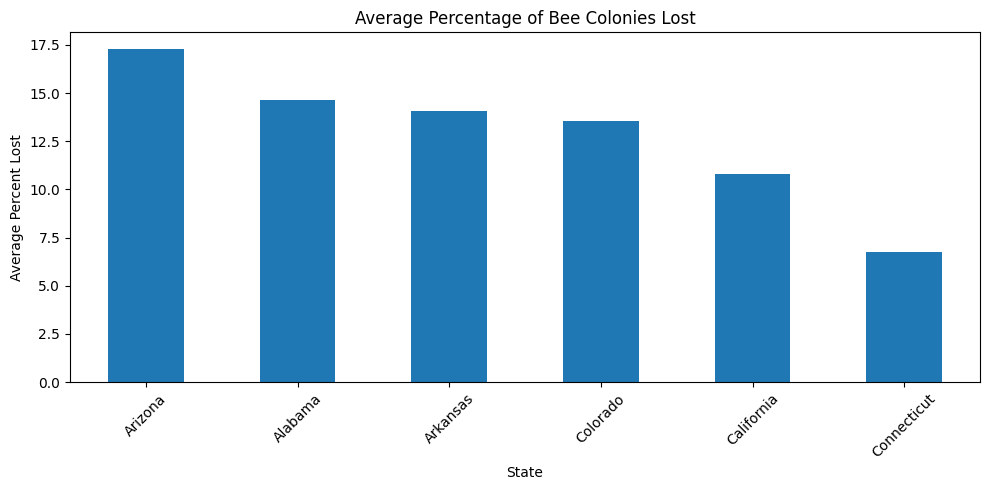


Total number of colonies:
state
California     27910000
Arizona          866000
Arkansas         657000
Colorado         573300
Alabama          260000
Connecticut      112100
Name: num_colonies, dtype: int64


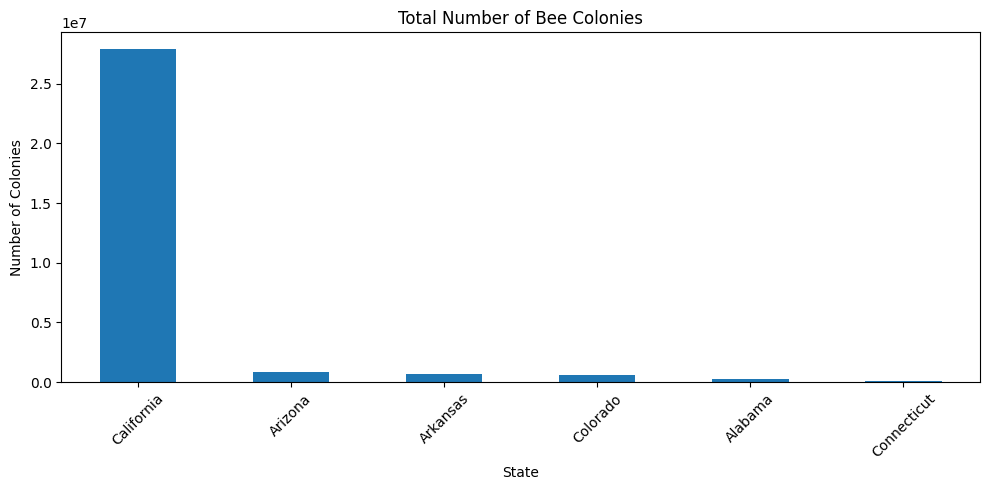


Average percentage lost by year and state:
state    Alabama    Arizona   Arkansas  California  Colorado  Connecticut
year                                                                     
2015   15.500000  19.000000  16.000000   11.750000     11.25     8.250000
2016   14.750000  18.000000  11.750000   12.000000     12.00     7.750000
2017   13.000000  17.250000  19.250000   11.250000     12.75     7.250000
2018   13.000000  20.250000  18.500000   11.750000     15.00     4.500000
2019   12.333333  12.333333  13.666667   12.666667     20.00     7.333333
2020   19.750000  18.500000   9.500000   10.750000     15.75     6.750000
2021   16.500000  21.250000  12.000000    9.000000     14.50     7.250000
2022   11.750000  10.500000  11.750000    7.750000      8.75     5.000000


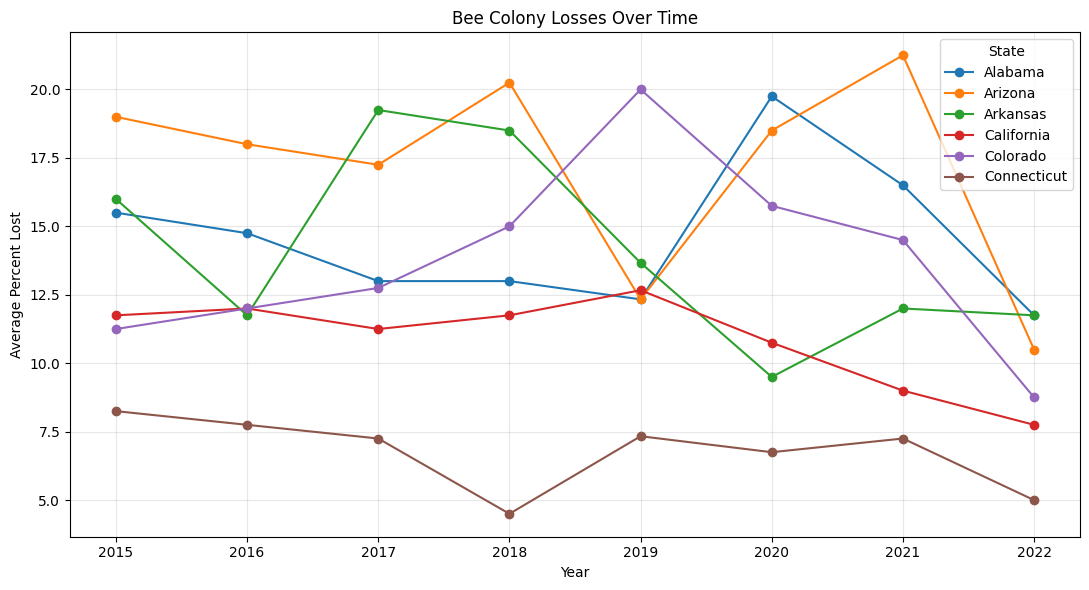

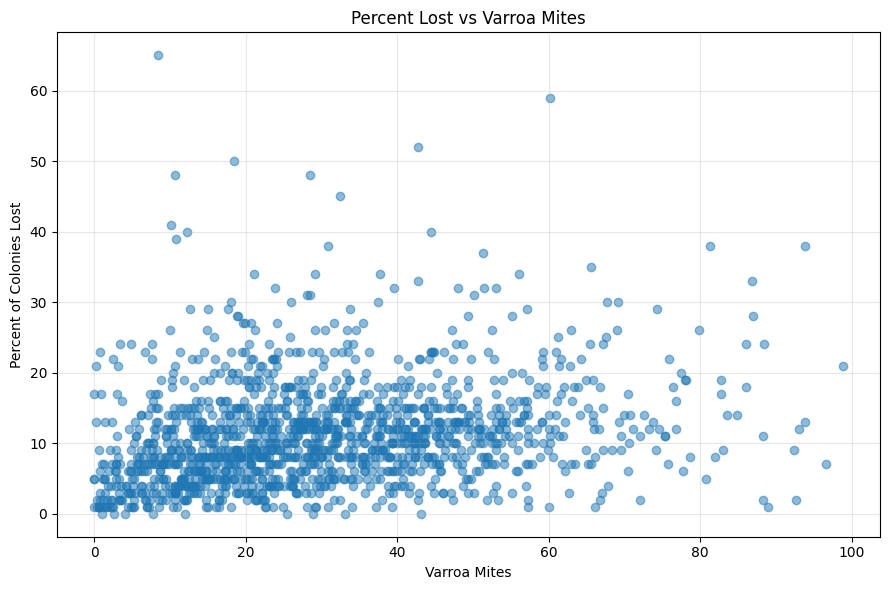

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


# --------------------------------------------------
# 1. Load the dataset
# --------------------------------------------------

df = pd.read_csv("save_the_bees.csv")


# --------------------------------------------------
# 2. Examine the dataset
# --------------------------------------------------

print("First five rows:")
print(df.head())

print("\nLast five rows:")
print(df.tail())

print("\nOriginal columns:")
print(df.columns)

print("\nDataset shape:")
print(df.shape)

print("\nDataset information:")
df.info()


# --------------------------------------------------
# 3. Make column names easier to use
# --------------------------------------------------

df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

print("\nCleaned column names:")
print(df.columns)


# --------------------------------------------------
# 4. Convert important columns to numbers
# --------------------------------------------------

numeric_columns = [
    "num_colonies",
    "percent_lost",
    "varroa_mites",
]

for column in numeric_columns:
    if column in df.columns:
        df[column] = pd.to_numeric(
            df[column]
            .astype(str)
            .str.replace(",", "", regex=False)
            .str.replace("%", "", regex=False),
            errors="coerce",
        )


# --------------------------------------------------
# 5. Create a year column if necessary
# --------------------------------------------------

if "year" not in df.columns:
    if "time" in df.columns:
        df["time"] = pd.to_datetime(df["time"], errors="coerce")
        df["year"] = df["time"].dt.year
    else:
        raise KeyError("The dataset does not contain a 'year' or 'time' column.")


# --------------------------------------------------
# 6. Look at the state column
# --------------------------------------------------

print("\nFirst five states:")
print(df["state"].head())

print("\nAvailable states:")
print(df["state"].dropna().unique())


# Select six states automatically.
# Replace this list with your preferred states if needed.

all_states = sorted(df["state"].dropna().unique())

states = [
    state for state in all_states if state not in {"United States", "Other States"}
][:6]

print("\nSelected states:")
print(states)

selected_states = df[df["state"].isin(states)].copy()


# --------------------------------------------------
# 7. Average percent lost for six states
# --------------------------------------------------

average_percent_lost = (
    selected_states.groupby("state")["percent_lost"].mean().sort_values(ascending=False)
)

print("\nAverage percent lost:")
print(average_percent_lost)

fig, ax = plt.subplots(figsize=(10, 5))

average_percent_lost.plot(
    kind="bar",
    ax=ax,
)

ax.set_title("Average Percentage of Bee Colonies Lost")
ax.set_xlabel("State")
ax.set_ylabel("Average Percent Lost")
ax.tick_params(axis="x", rotation=45)

fig.tight_layout()
plt.show()


# --------------------------------------------------
# 8. Total number of colonies for six states
# --------------------------------------------------

total_colonies = (
    selected_states.groupby("state")["num_colonies"].sum().sort_values(ascending=False)
)

print("\nTotal number of colonies:")
print(total_colonies)

fig, ax = plt.subplots(figsize=(10, 5))

total_colonies.plot(
    kind="bar",
    ax=ax,
)

ax.set_title("Total Number of Bee Colonies")
ax.set_xlabel("State")
ax.set_ylabel("Number of Colonies")
ax.tick_params(axis="x", rotation=45)

fig.tight_layout()
plt.show()


# --------------------------------------------------
# 9. Colony losses over time
# --------------------------------------------------

losses_over_time = (
    selected_states.groupby(["year", "state"])["percent_lost"]
    .mean()
    .unstack()
    .sort_index()
)

print("\nAverage percentage lost by year and state:")
print(losses_over_time)

fig, ax = plt.subplots(figsize=(11, 6))

losses_over_time.plot(
    kind="line",
    marker="o",
    ax=ax,
)

ax.set_title("Bee Colony Losses Over Time")
ax.set_xlabel("Year")
ax.set_ylabel("Average Percent Lost")
ax.legend(title="State")
ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()


# --------------------------------------------------
# 10. Percent lost compared with varroa mites
# --------------------------------------------------

scatter_data = df[["percent_lost", "varroa_mites"]].dropna()

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(
    scatter_data["varroa_mites"],
    scatter_data["percent_lost"],
    alpha=0.5,
)

ax.set_title("Percent Lost vs Varroa Mites")
ax.set_xlabel("Varroa Mites")
ax.set_ylabel("Percent of Colonies Lost")
ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()
